## DS-450 Capstone EDA and Modeling

### Variables:
##### This time series data is formatted with each of these variables, for each repective department, for that 
##### given week for each week in 2023-25:
- **Date**: The only non-repeating variable; tells the week and year of the observation. The dtype is datetime64.

- **Actual Sales**: Sales in dollars from the given department.

- **Actual Sales per Labor Hour**: Sales in dollars per actual hour of labor.

- **Actual AHR**: Average hourly rate.

- **Actual Hours**: The actual number of hours expended by that department.

- **Actual % Effective**: Percentage of actual hours that are productive.

- **Actual Overtime Hours**: Number of hours overtime.

- **Actual Overtime Wages**: Amount of wages paid to overtime hours.

- **Actual Overtime %**: Percent of total hours which are overtime.

- **Forecast Fixed Hours**: Forecasted future fixed hours (forecasting 2 weeks ahead).

- **Forecast Variable Hours**: Forecasted variable hours.

- **Earned Hours @ 100%**: The hours earned and delegated to that department a given week.ven week.

##### Most of these variables are of dtype float64 with exception to 25 observations, which I
##### attribute to inconsistent data entry and should not negetively affect the EDA/Modeling

### Questions and Ideas to Consider:
- Labor Productivity: Are actual hours, given sales, alligning with demand? 
- Labor Efficiency: Earned Hours @ 100% / Actual Hours = Efficiency; was that week over or underscheduled or perfectly scheduled?
- Overtime: Given variables, will overtme occur in a given week or no? 
- POS: Does more/less SCO hours correlate with more/less register hours? 
- Can hours required be predicted given sales?

### Preprocessing

In [1]:
#Importing libraries for processing and modeling. 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [3]:
data = pd.read_excel('Mrdak_339Data.xlsx', sheet_name = 'Formatted Data')

data.head(3)

,Date,Front End Actual Sales,Actual Sales per Labor Hour,Actual AHR,Actual Hours,Actual % Effective,Actual Overtime Hours,Actual Overtime Wages,Actual Overtime %,Forecast Fixed Hours,...,Actual Sales per Labor Hour.31,Actual AHR.31,Actual Hours.31,Actual % Effective.31,Actual Overtime Hours.31,Actual Overtime Wages.31,Actual Overtime %.31,Forecast Fixed Hours.31,Forecast Variable Hours.31,Earned Hours @ 100%.31
0,2025 W52,279759.70,381.273867,17.347023,733.75,1.018126,10.5,324.60,0.013623,427.868,...,262.726048,19.567576,3305.169,1.119650,77.67,2461.46,0.022873,1486.910,2405.520,3700.632
1,2025 W51,630969.57,759.746623,17.593305,830.50,1.136783,12.0,414.02,0.013348,432.523,...,433.772959,19.685112,3971.580,1.074125,140.25,4433.28,0.034364,1524.371,2324.092,4265.974
2,2025 W50,381923.73,427.925748,17.563818,892.50,0.877812,25.5,822.01,0.026323,428.358,...,298.639510,19.555287,4044.500,0.981083,145.50,4473.35,0.035045,1518.424,2408.436,3967.990


In [4]:
print(f'The data is {data.shape[0]} rows by {data.shape[1]} columns.')

The data is 159 rows by 353 columns.


In [5]:
#missing_percentage = (data.isnull().sum() / len(data))
#((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

In [6]:
#for col in data.columns:
    #print(col)

In [7]:
#Dropping columns related to coffee, fuel, and grocery/gm combined. 
data = data.drop([
'Coffee Actual Sales',
'Actual Sales per Labor Hour.22',
'Actual AHR.22',
'Actual Hours.22',
'Actual % Effective.22',
'Actual Overtime Hours.22',
'Actual Overtime Wages.22',
'Actual Overtime %.22',
'Forecast Fixed Hours.22',
'Forecast Variable Hours.22',
'Earned Hours @ 100%.22',
'Without Fuel Actual Sales',
'Actual Sales per Labor Hour.29',
'Actual AHR.29',
'Actual Hours.29',
'Actual % Effective.29',
'Actual Overtime Hours.29',
'Actual Overtime Wages.29',
'Actual Overtime %.29',
'Forecast Fixed Hours.29',
'Forecast Variable Hours.29',
'Earned Hours @ 100%.29',
'Fuel Actual Sales',
'Actual Sales per Labor Hour.30',
'Actual AHR.30',
'Actual Hours.30',
'Actual % Effective.30',
'Actual Overtime Hours.30',
'Actual Overtime Wages.30',
'Actual Overtime %.30',
'Forecast Fixed Hours.30',
'Forecast Variable Hours.30',
'Earned Hours @ 100%.30',
'Grocery & HBC/GM Actual Sales',
'Actual Sales per Labor Hour.14',
'Actual AHR.14',
'Actual Hours.14',
'Actual % Effective.14',
'Actual Overtime Hours.14',
'Actual Overtime Wages.14',
'Actual Overtime %.14',
'Forecast Fixed Hours.14',
'Forecast Variable Hours.14',
'Earned Hours @ 100%.14'], axis = 1)

#for col in data.columns:
    #print(col)

In [8]:
print(f'The data is now {data.shape[0]} rows by {data.shape[1]} columns.')

The data is now 159 rows by 309 columns.


### Analysis

In [9]:
### Note to self dont run the cell below more than once w/o restarting the kernel

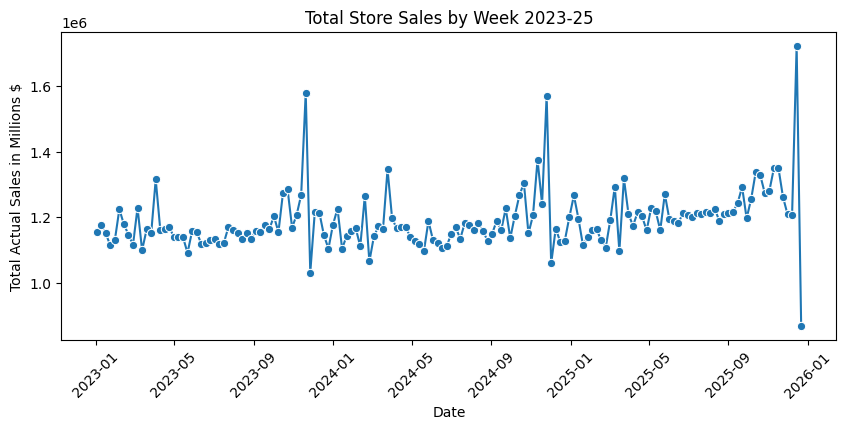

In [10]:
#Converting the values in 'Date' into a presentable format
#Removing 'Average' from Date. 
data = data[data['Date'].str.strip() != 'Average']
data["Date"] = pd.to_datetime(data["Date"] + "-1", format = "%G W%V-%u")
data = data.sort_values("Date")
#Generating the Lineplot
plt.figure(figsize = (10, 4))

sns.lineplot(
    x = "Date",
    y = "Total Actual Sales",
    data = data,
    marker = "o" 
)
plt.title('Total Store Sales by Week 2023-25')
plt.ylabel('Total Actual Sales in Millions $')
plt.xticks(rotation = 45)
plt.show()


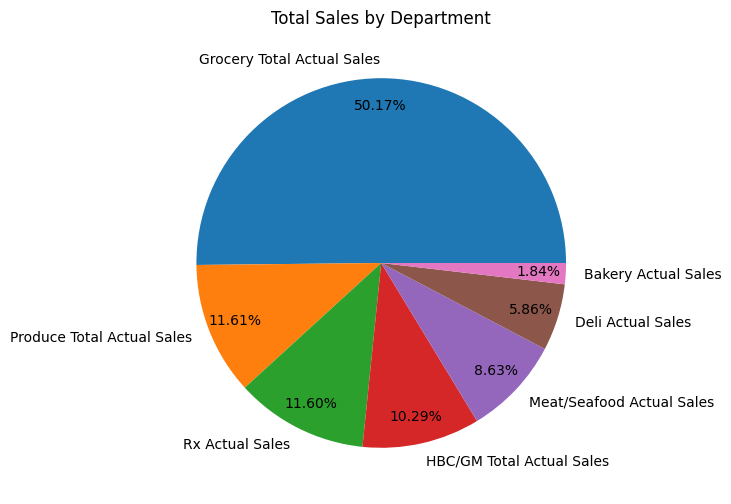

In [11]:
data[['Grocery Total Actual Sales', 'HBC/GM Total Actual Sales', 'Produce Total Actual Sales',\
      'Meat/Seafood Actual Sales', 'Deli Actual Sales', 'Bakery Actual Sales', 'Rx Actual Sales']].sum().sort_values(ascending=False)\
.plot(kind='pie',figsize=(8,6),title="Total Sales by Department",
    pctdistance = 0.85,
    labeldistance = 1.1,
    autopct = '%1.2f%%')
plt.show()

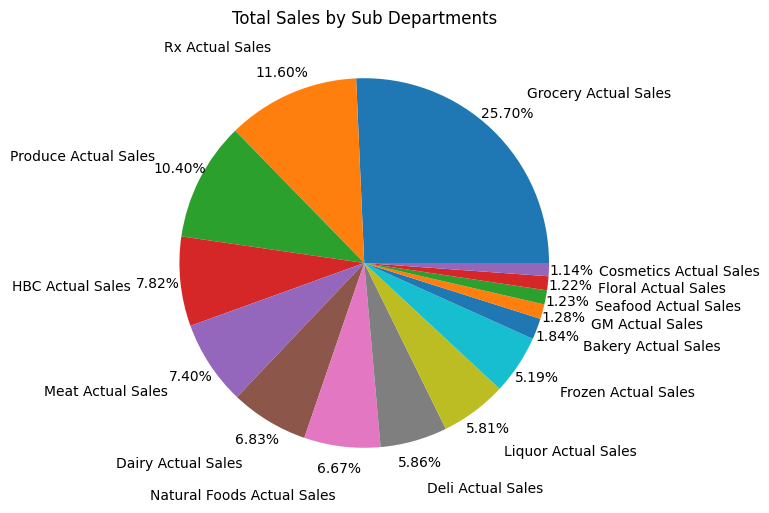

In [12]:
data[['Grocery Actual Sales', 'Dairy Actual Sales', 'Frozen Actual Sales', 'Liquor Actual Sales', 'Natural Foods Actual Sales',\
      'HBC Actual Sales', 'Cosmetics Actual Sales', 'GM Actual Sales', 'Produce Actual Sales', 'Floral Actual Sales',\
      'Meat Actual Sales', 'Seafood Actual Sales', 'Deli Actual Sales', 'Bakery Actual Sales', 'Rx Actual Sales']].sum().sort_values(ascending=False)\
.plot(kind='pie',figsize=(8,6),title="Total Sales by Sub Departments",
    pctdistance = 1.12,
    labeldistance = 1.27,
    autopct = '%1.2f%%')
plt.show()

In [13]:
#corr=data[['Front End Actual Sales','Self Checkout Actual Sales']].corr()

#sns.heatmap(corr,annot=True)
#plt.title("Front End vs Self Checkout Sales")
#plt.show()

In [14]:
#corr=data[['Actual Sales per Labor Hour','Actual Sales per Labor Hour.1']].corr()

#sns.heatmap(corr,annot=True)
#plt.title("Front End vs Self Checkout(.1) Sales per Labor Hour")
#plt.xticks(rotation = 30)
#plt.show()

Correlation matrices show there is a strong correlation between front end and sco total sales,
but no correlation between sales per labor hour...

### Random Forest Regression Model

In [15]:
#Question to answer with this model is: Can I predict the actual hours consumed in a given week?
#First need to separate 'Date' into weeks, months, and years, into a datatype that is interpretable for the model. 

data['week'] = data['Date'].dt.isocalendar().week
data['month'] = data['Date'].dt.month
data['year'] = data['Date'].dt.year
#isocalendar is week counting in pandas
#.dt to convert into specified date/time

#print(data[['Date', 'week', 'month', 'year']].head(-5))

C:\Users\nikol\AppData\Local\Temp\ipykernel_13388\911578220.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['week'] = data['Date'].dt.isocalendar().week
C:\Users\nikol\AppData\Local\Temp\ipykernel_13388\911578220.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['month'] = data['Date'].dt.month
C:\Users\nikol\AppData\Local\Temp\ipykernel_13388\911578220.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider 

In [16]:
print(data[['week', 'month', 'year']].dtypes)

week     UInt32
month     int32
year      int32
dtype: object


In [17]:
#IMPORTANT
#Holding five random observations from the model
#To be used to verify the performance. 
#Goal is showing actual v predicted actual hours. 

#Excluding 'Date', but incorporating its week, month, & year.
X = data[[
    'week', 'month', 'year', 'Grocery Actual Sales', 'Actual Sales per Labor Hour.3', 'Forecast Fixed Hours.3', 'Forecast Variable Hours.3',
'Dairy Actual Sales', 'Actual Sales per Labor Hour.4', 'Forecast Fixed Hours.4', 'Forecast Variable Hours.4',
'Frozen Actual Sales', 'Actual Sales per Labor Hour.5', 'Forecast Fixed Hours.5', 'Forecast Variable Hours.5',
'Liquor Actual Sales', 'Actual Sales per Labor Hour.6', 'Forecast Fixed Hours.6', 'Forecast Variable Hours.6',
'Natural Foods Actual Sales', 'Actual Sales per Labor Hour.7', 'Forecast Fixed Hours.7', 'Forecast Variable Hours.7',
'HBC Actual Sales', 'Actual Sales per Labor Hour.9', 'Forecast Fixed Hours.9', 'Forecast Variable Hours.9',
'Cosmetics Actual Sales', 'Actual Sales per Labor Hour.10', 'Forecast Fixed Hours.10', 'Forecast Variable Hours.10',
'GM Actual Sales', 'Actual Sales per Labor Hour.11', 'Forecast Fixed Hours.11', 'Forecast Variable Hours.11',
'Apparel Actual Sales', 'Actual Sales per Labor Hour.12', 'Forecast Fixed Hours.12', 'Forecast Variable Hours.12',
'Produce Actual Sales', 'Actual Sales per Labor Hour.15', 'Forecast Fixed Hours.15', 'Forecast Variable Hours.15',
'Floral Actual Sales', 'Actual Sales per Labor Hour.16', 'Forecast Fixed Hours.16', 'Forecast Variable Hours.16',
'Meat Actual Sales', 'Actual Sales per Labor Hour.18', 'Forecast Fixed Hours.18', 'Forecast Variable Hours.18',
'Seafood Actual Sales', 'Actual Sales per Labor Hour.19', 'Forecast Fixed Hours.19', 'Forecast Variable Hours.19',
'Deli Actual Sales', 'Actual Sales per Labor Hour.21', 'Forecast Fixed Hours.21', 'Forecast Variable Hours.21',
'Bakery Actual Sales', 'Actual Sales per Labor Hour.24', 'Forecast Fixed Hours.24', 'Forecast Variable Hours.24',
'Rx Actual Sales', 'Actual Sales per Labor Hour.28', 'Forecast Fixed Hours.28', 'Forecast Variable Hours.28'
]]
y = data['Actual Hours.31']


In [92]:
#Model 2 excluding forecast fixed and variable
X = data[[
    'week', 'month', 'year', 'Grocery Actual Sales', 'Actual Sales per Labor Hour.3',
'Dairy Actual Sales', 'Actual Sales per Labor Hour.4', 
'Frozen Actual Sales', 'Actual Sales per Labor Hour.5', 
'Liquor Actual Sales', 'Actual Sales per Labor Hour.6', 
'Natural Foods Actual Sales', 'Actual Sales per Labor Hour.7', 
'HBC Actual Sales', 'Actual Sales per Labor Hour.9', 
'Cosmetics Actual Sales', 'Actual Sales per Labor Hour.10', 
'GM Actual Sales', 'Actual Sales per Labor Hour.11', 
'Apparel Actual Sales', 'Actual Sales per Labor Hour.12', 
'Produce Actual Sales', 'Actual Sales per Labor Hour.15', 
'Floral Actual Sales', 'Actual Sales per Labor Hour.16', 
'Meat Actual Sales', 'Actual Sales per Labor Hour.18', 
'Seafood Actual Sales', 'Actual Sales per Labor Hour.19', 
'Deli Actual Sales', 'Actual Sales per Labor Hour.21', 
'Bakery Actual Sales', 'Actual Sales per Labor Hour.24',
'Rx Actual Sales', 'Actual Sales per Labor Hour.28'
]]
y = data['Actual Hours.31']


In [93]:
testersX = X.sample(n = 5, random_state = 24)
testersy = y.sample(n = 5, random_state = 24)


model1 = data.drop(testersX.index)
model1 = data.drop(testersy.index)

In [94]:
#Actual Hours Forest
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .20, random_state = 42)
#X_train.info()
#Recall the random_state ensures the same split of data, but in forest, rs goes in model not data split.

In [21]:
#for col in data.columns:
    #print(col)

In [95]:
model1 = RandomForestRegressor(n_estimators = 200, random_state = 42)
model1.fit(X_train.values, y_train.values)
#n_estimators is how many trees; 100-300 is good start
y_pred = model1.predict(X_test.values)

In [23]:
pd.set_option('display.max_rows', None)

In [96]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
print("MAE: ", mae)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE: ", rmse)

r2 = r2_score(y_test, y_pred)
print("r2: ", r2)

significances = model1.feature_importances_
#formating the significances: variable/feature and their significance
sig_df = pd.DataFrame({
    'feature':X.columns,
    'sig':model1.feature_importances_
}).sort_values(by = 'sig', ascending = False)


print(sig_df)
print(f'SUM:')
print(model1.feature_importances_.sum())

MAE:  129.3822612499997
RMSE:  186.6134516433287
r2:  0.33989077250371114
                           feature       sig
32  Actual Sales per Labor Hour.24  0.107181
15          Cosmetics Actual Sales  0.080377
13                HBC Actual Sales  0.068385
27            Seafood Actual Sales  0.067915
31             Bakery Actual Sales  0.065529
4    Actual Sales per Labor Hour.3  0.055133
29               Deli Actual Sales  0.054880
9              Liquor Actual Sales  0.050880
23             Floral Actual Sales  0.044153
5               Dairy Actual Sales  0.040066
7              Frozen Actual Sales  0.038757
25               Meat Actual Sales  0.038272
3             Grocery Actual Sales  0.031851
21            Produce Actual Sales  0.029555
0                             week  0.024781
10   Actual Sales per Labor Hour.6  0.020797
11      Natural Foods Actual Sales  0.019733
30  Actual Sales per Labor Hour.21  0.017641
17                 GM Actual Sales  0.017191
19            Apparel Actu

In [37]:
for col in X.columns:
    print(col)

week
month
year
Grocery Actual Sales
Actual Sales per Labor Hour.3
Forecast Fixed Hours.3
Forecast Variable Hours.3
Dairy Actual Sales
Actual Sales per Labor Hour.4
Forecast Fixed Hours.4
Forecast Variable Hours.4
Frozen Actual Sales
Actual Sales per Labor Hour.5
Forecast Fixed Hours.5
Forecast Variable Hours.5
Liquor Actual Sales
Actual Sales per Labor Hour.6
Forecast Fixed Hours.6
Forecast Variable Hours.6
Natural Foods Actual Sales
Actual Sales per Labor Hour.7
Forecast Fixed Hours.7
Forecast Variable Hours.7
HBC Actual Sales
Actual Sales per Labor Hour.9
Forecast Fixed Hours.9
Forecast Variable Hours.9
Cosmetics Actual Sales
Actual Sales per Labor Hour.10
Forecast Fixed Hours.10
Forecast Variable Hours.10
GM Actual Sales
Actual Sales per Labor Hour.11
Forecast Fixed Hours.11
Forecast Variable Hours.11
Apparel Actual Sales
Actual Sales per Labor Hour.12
Forecast Fixed Hours.12
Forecast Variable Hours.12
Produce Actual Sales
Actual Sales per Labor Hour.15
Forecast Fixed Hours.15
Fore

The output from this forest regression model indicates that in predicting total store hours for a given week, total sales have the most influence. second to sales per labor hour, which makes sense as total sales and sales per labor hour are theoretically correlated. Although small, week had the most significance over month and year, suggesting that the seasonality of holidays would slighlty influence the hours worked in a given week. These findings strognly align with common sense. 

Second iteration of this model removed forecasted fixed and variable hours. While the performance of the model dipped, smaller departments in terms of sales became more significant. This second version shows that not just fixed and variable hours perdict actual hours, can be predicted from operations. 

### Using testers to observe predicted versus actual values for actual hours

In [25]:
#X_testers = testers.drop(columns = ['Actual Hours.31'])
#y_testers = testers['Actual Hours.31']
                         

In [97]:
tmodel = model1.predict(testersX)

compare = pd.DataFrame({
    'Actual Hours':testersy,
    'Predicted Hours':tmodel
})

print(compare)

     Actual Hours  Predicted Hours
109      4329.750      4233.238075
99       4152.000      4125.174790
138      3817.830      3980.073985
29       4118.500      4075.220340
44       3917.079      3947.563010


C:\Users\nikol\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [98]:
mae_test = mean_absolute_error(testersy, tmodel)

print('Testers MAE:', mae_test)

Testers MAE: 71.86895800000211


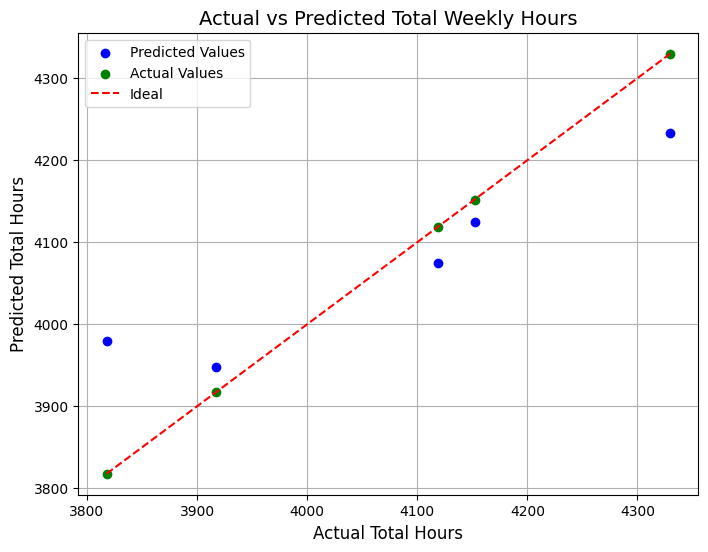

In [53]:
#Scatter plot for predictions compared to actual
actual = list(testersy.values)
predicted = list(tmodel)
 
plt.figure(figsize=(8, 6))
plt.scatter(actual, predicted, color='blue', label='Predicted Values')
plt.scatter(actual, actual, color='green', label='Actual Values')
plt.plot([min(actual), max(actual)], [min(actual), max(actual)], color='red', linestyle='--', label='Ideal')

plt.xlabel('Actual Total Hours', fontsize=12)
plt.ylabel('Predicted Total Hours', fontsize=12)
plt.title('Actual vs Predicted Total Weekly Hours', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

In [54]:
mape = np.mean(np.abs((testersy - tmodel) / testersy)) * 100

print(f'MAPE: {mape:.2f}%')

MAPE: 1.79%


In [55]:
#Joining all variables with 2% or less significance
#
larges = sig_df[sig_df['sig'] >= 0.02]
smalls = sig_df[sig_df['sig'] < 0.02]

# combine small ones
other_sums = smalls['sig'].sum()

# append "Other" if any exist
if other_sums > 0:
    larges = pd.concat([
        larges,
        pd.DataFrame({'feature': ['Others'], 'sig': [other_sums]})
    ])

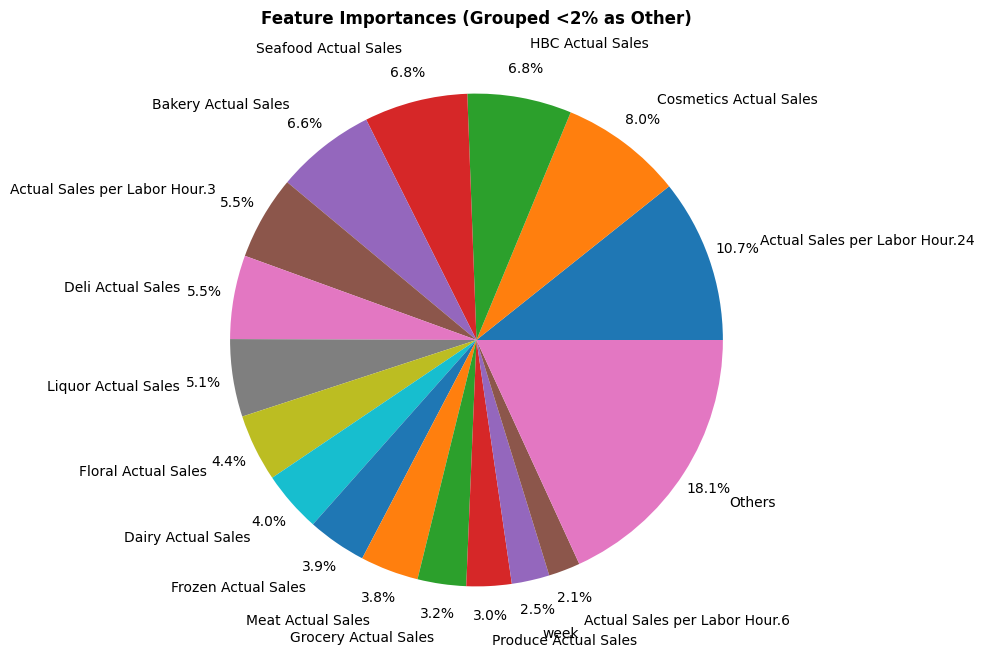

In [56]:
plt.figure(figsize = (10, 8))

plt.pie(
    larges['sig'],
    labels = larges['feature'],
    autopct = '%1.1f%%',
    pctdistance = 1.12,
    labeldistance = 1.22
)

plt.title('Feature Importances (Grouped <2% as Other)', fontweight = 'bold')
plt.show()

In [99]:
top5 = sig_df.head(5).copy()
top5['percent'] = top5['sig'] * 100

In [100]:
dept_map = {
    '.3': 'Grocery',
    '.4': 'Dairy',
    '.5': 'Frozen',
    '.6': 'Liquor',
    '.7': 'Natural Foods',
    '.9': 'HBC',
    '.10': 'Cosmetics',
    '.11': 'GM',
    '.12': 'Apparel',
    '.15': 'Produce',
    '.16': 'Floral',
    '.18': 'Meat',
    '.19': 'Seafood',
    '.21': 'Deli',
    '.24': 'Bakery',
    '.28': 'Rx'
}

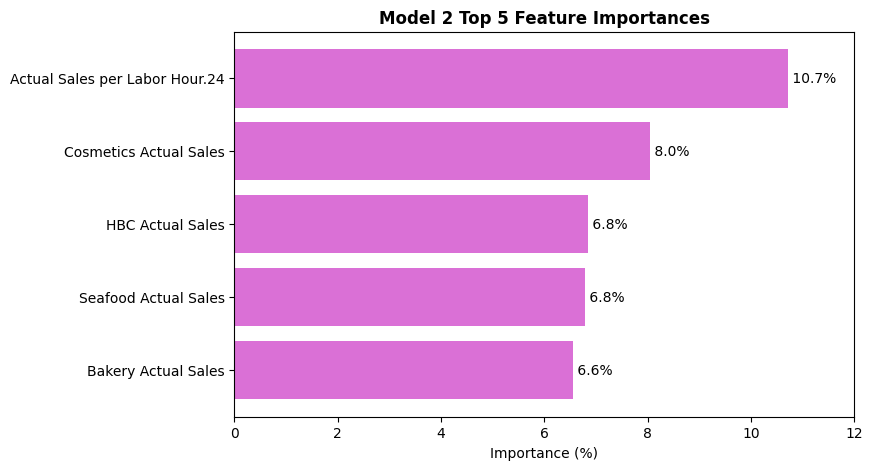

In [102]:
plt.figure(figsize = (8,5))

plt.barh(top5['feature'], top5['percent'], color = 'orchid')
plt.gca().invert_yaxis()

for i, v in enumerate(top5['percent']):
    plt.text(v, i, f' {v:.1f}%', va = 'center')

plt.xlabel('Importance (%)')
plt.title('Model 2 Top 5 Feature Importances', fontweight = 'bold')
plt.xlim(0, 12)
plt.show()

In [32]:
print(f'Hi Juliet!')

Hi Juliet!
